# The convolution 

Splot - operacja, która z dwóch sygnałów robi trzeci, a w DSP jest odpowiedzią na fundamentalne pytanie: „co system albo filtr robi z sygnałem?"

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib import style

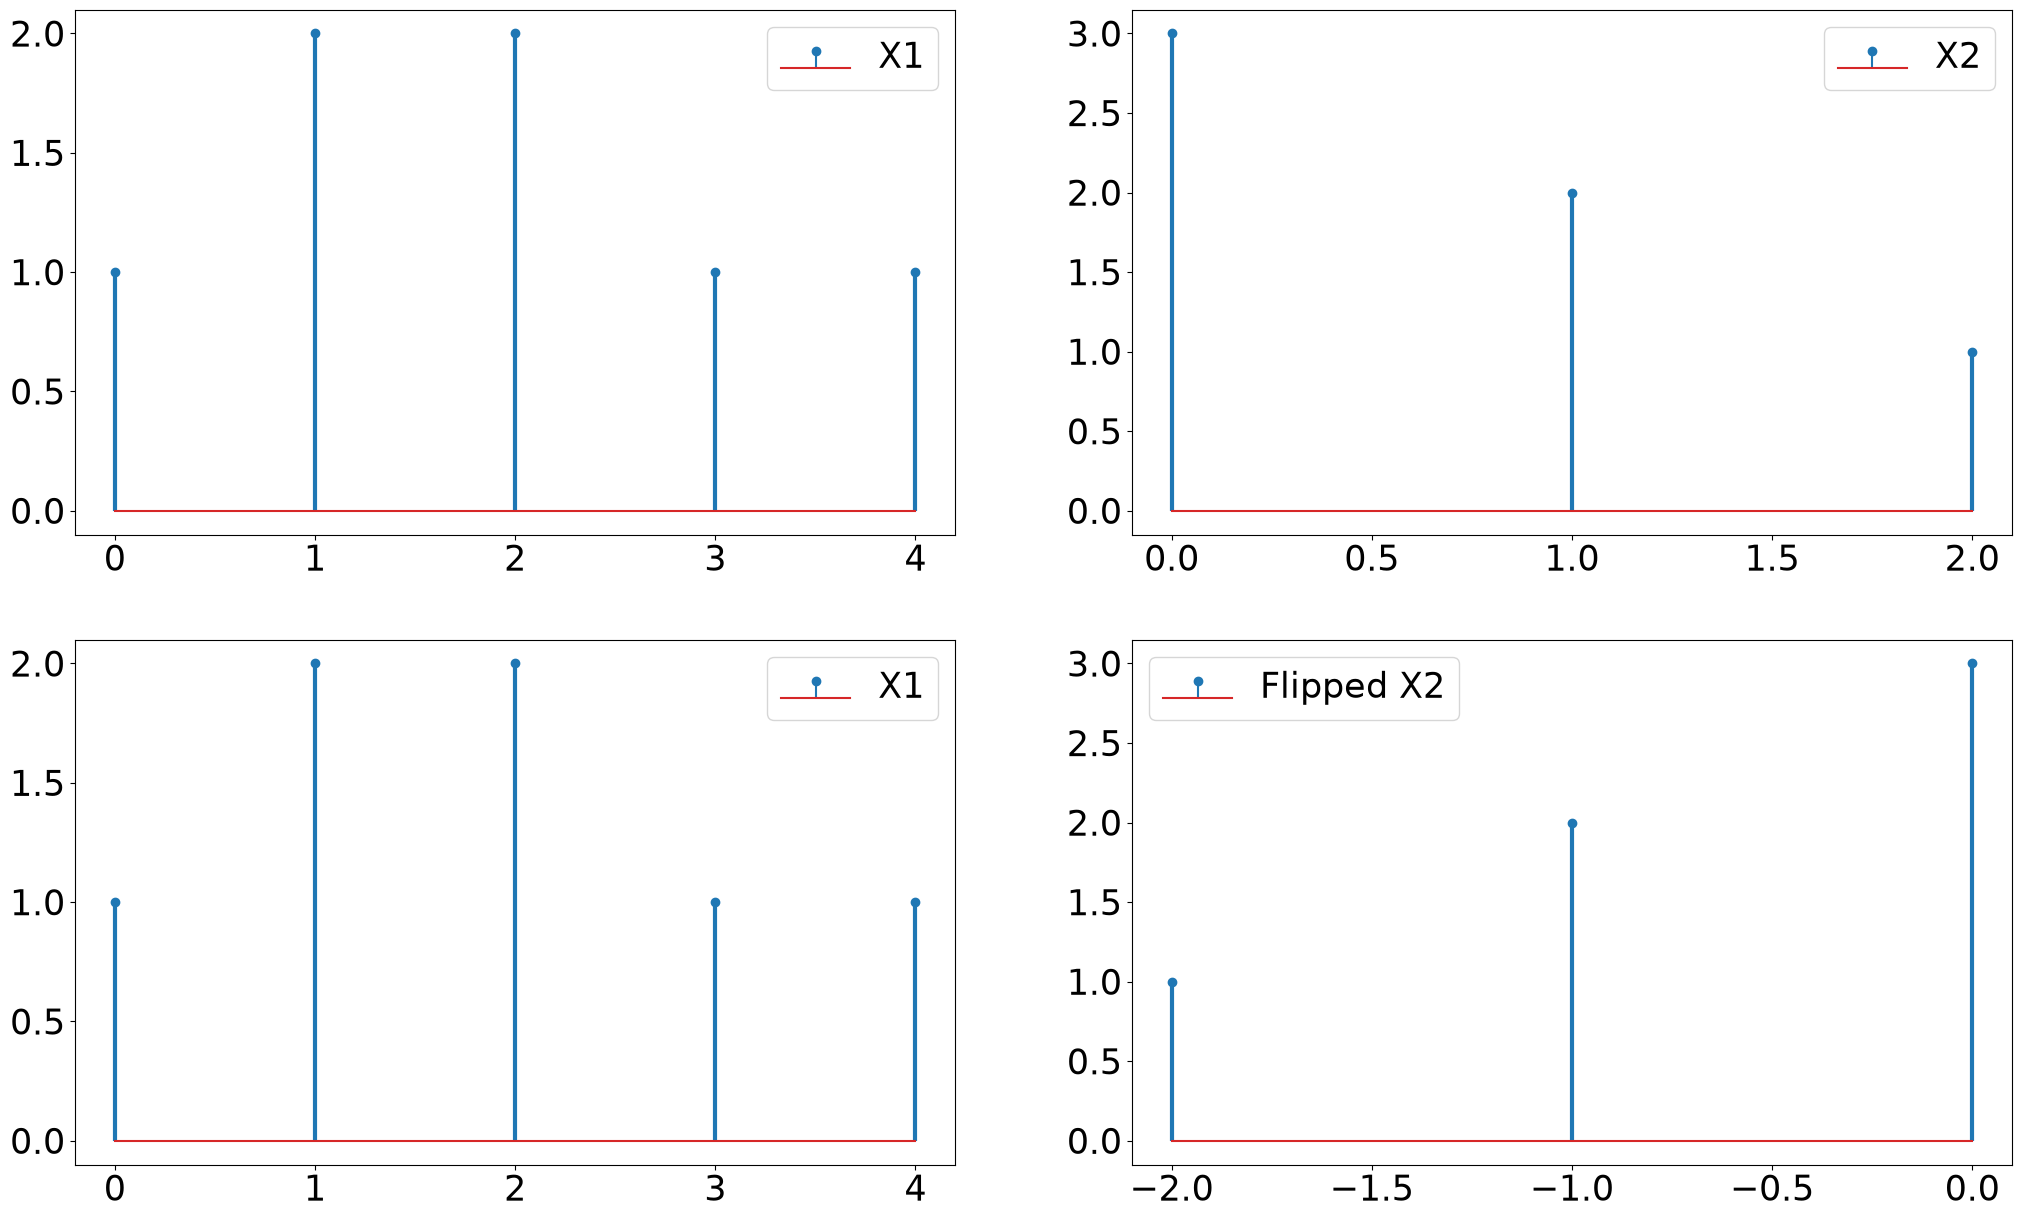

In [6]:
# Genrating and ploting X1 

x1 = np.array([1, 2, 2, 1, 1])
n1 = np.array([0, 1, 2, 3, 4])

plt.figure(figsize=(25,15))
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.subplot(2,2,1)
markerline, stemlines, baseline = plt.stem(n1, x1, label = 'X1')
plt.setp(stemlines, 'linewidth', 3)
plt.legend(fontsize = 25)


# Genrating and ploting X2 
x2 = np.array([3, 2, 1])
n2 = np.array([0, 1, 2])
plt.subplot(2,2,2)
markerline, stemlines, baseline = plt.stem(n2, x2, label = 'X2')
plt.setp(stemlines, 'linewidth', 3)
plt.legend(fontsize = 25)


# 3 position 
plt.subplot(2,2,3)
markerline, stemlines, baseline = plt.stem(n1, x1, label = 'X1')
plt.setp(stemlines, 'linewidth', 3)
plt.legend(fontsize = 25)

# Flipping X2 and plotting
flippedX2 = x2[::-1]
n3 = np.array([-2, -1,0])
plt.subplot(2,2,4)
markerline, stemlines, baseline = plt.stem(n3, flippedX2, label = 'Flipped X2')
plt.legend(fontsize = 25)
plt.setp(stemlines, 'linewidth', 3)

plt.show()

## Calculating convolution for mode = 'full'

In [7]:
nx1 = len(x1)  
nx2 = len(x2)
nconvol = nx1 + nx2 - 1

print(nx1)
print(nx2)
print(nconvol)


5
3
7


In [20]:
# Expanding x1 by zero padding
# zero padding means that you can increase the lenght of signal by adding zero (either at the start or at the end or o both)


half_nx2 = int(np.round(nx2/2))

data_4_convolution = np.concatenate((np.zeros(half_nx2), x1, np.zeros(half_nx2)), axis = 0 ) # adding zero ath the both sides of x1

print(half_nx2)
print(np.zeros(half_nx2))
print(data_4_convolution)

2
[0. 0.]
[0. 0. 1. 2. 2. 1. 1. 0. 0.]


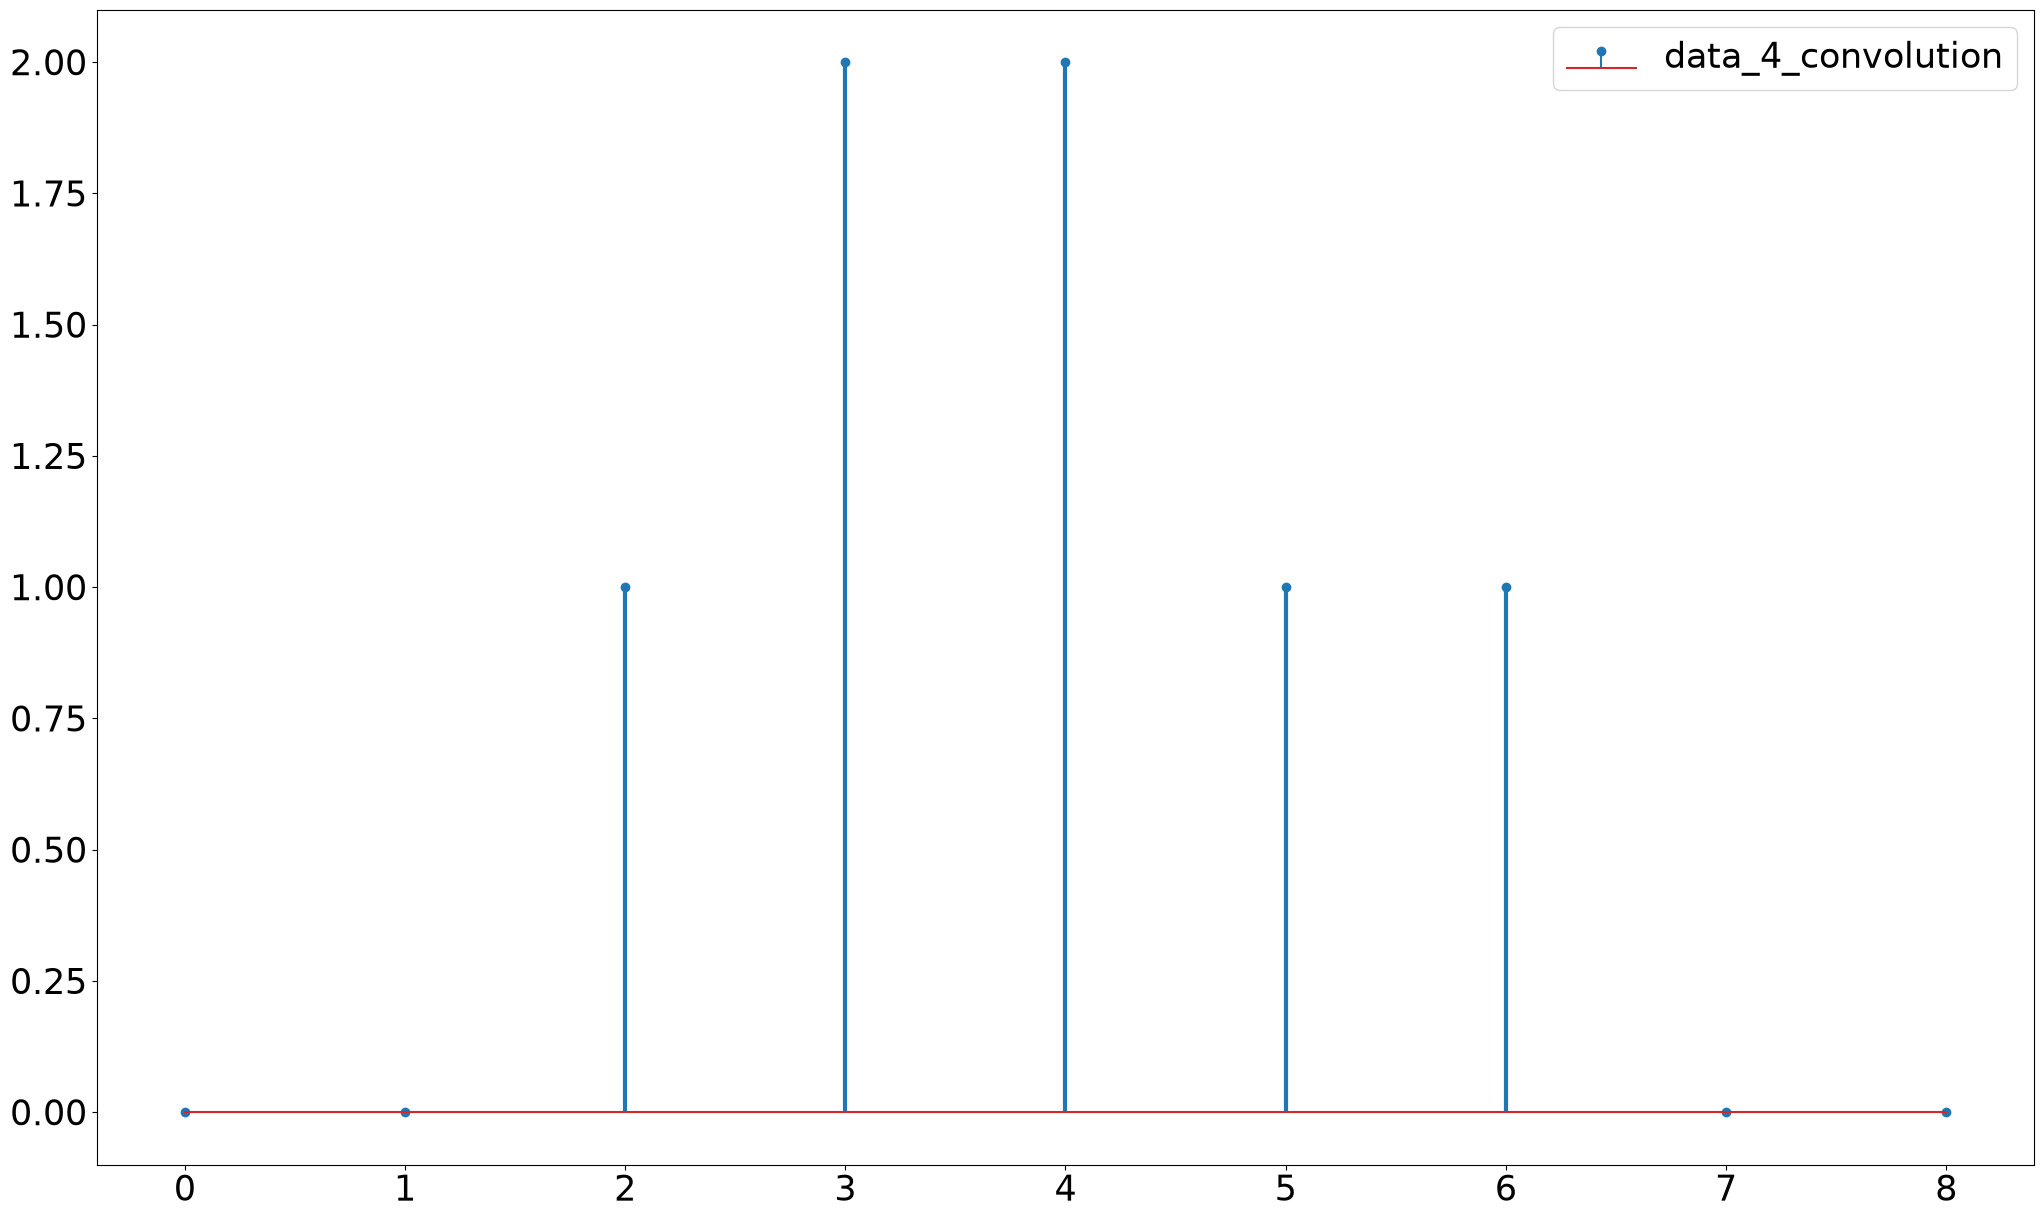

In [21]:
# Plotting data for convolution

plt.figure( figsize = (25,15))
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
markerline, stemlines, baseline = plt.stem(data_4_convolution, label = 'data_4_convolution')
plt.legend(fontsize = 25)
plt.setp(stemlines, 'linewidth', 3)

plt.show()

We require the filters to go through each and every sample of x1.
Zero expanding is the only method which allows us to expand x1or a signal for performing a full mode convolution.

## Convolution by for loops 

In [26]:
convres = np.zeros(nconvol)
for i in range (0, nconvol):
    convres[i] = np.sum(flippedX2 * data_4_convolution[i : i+nx2])
print(convres)

[ 3.  8. 11.  9.  7.  3.  1.]


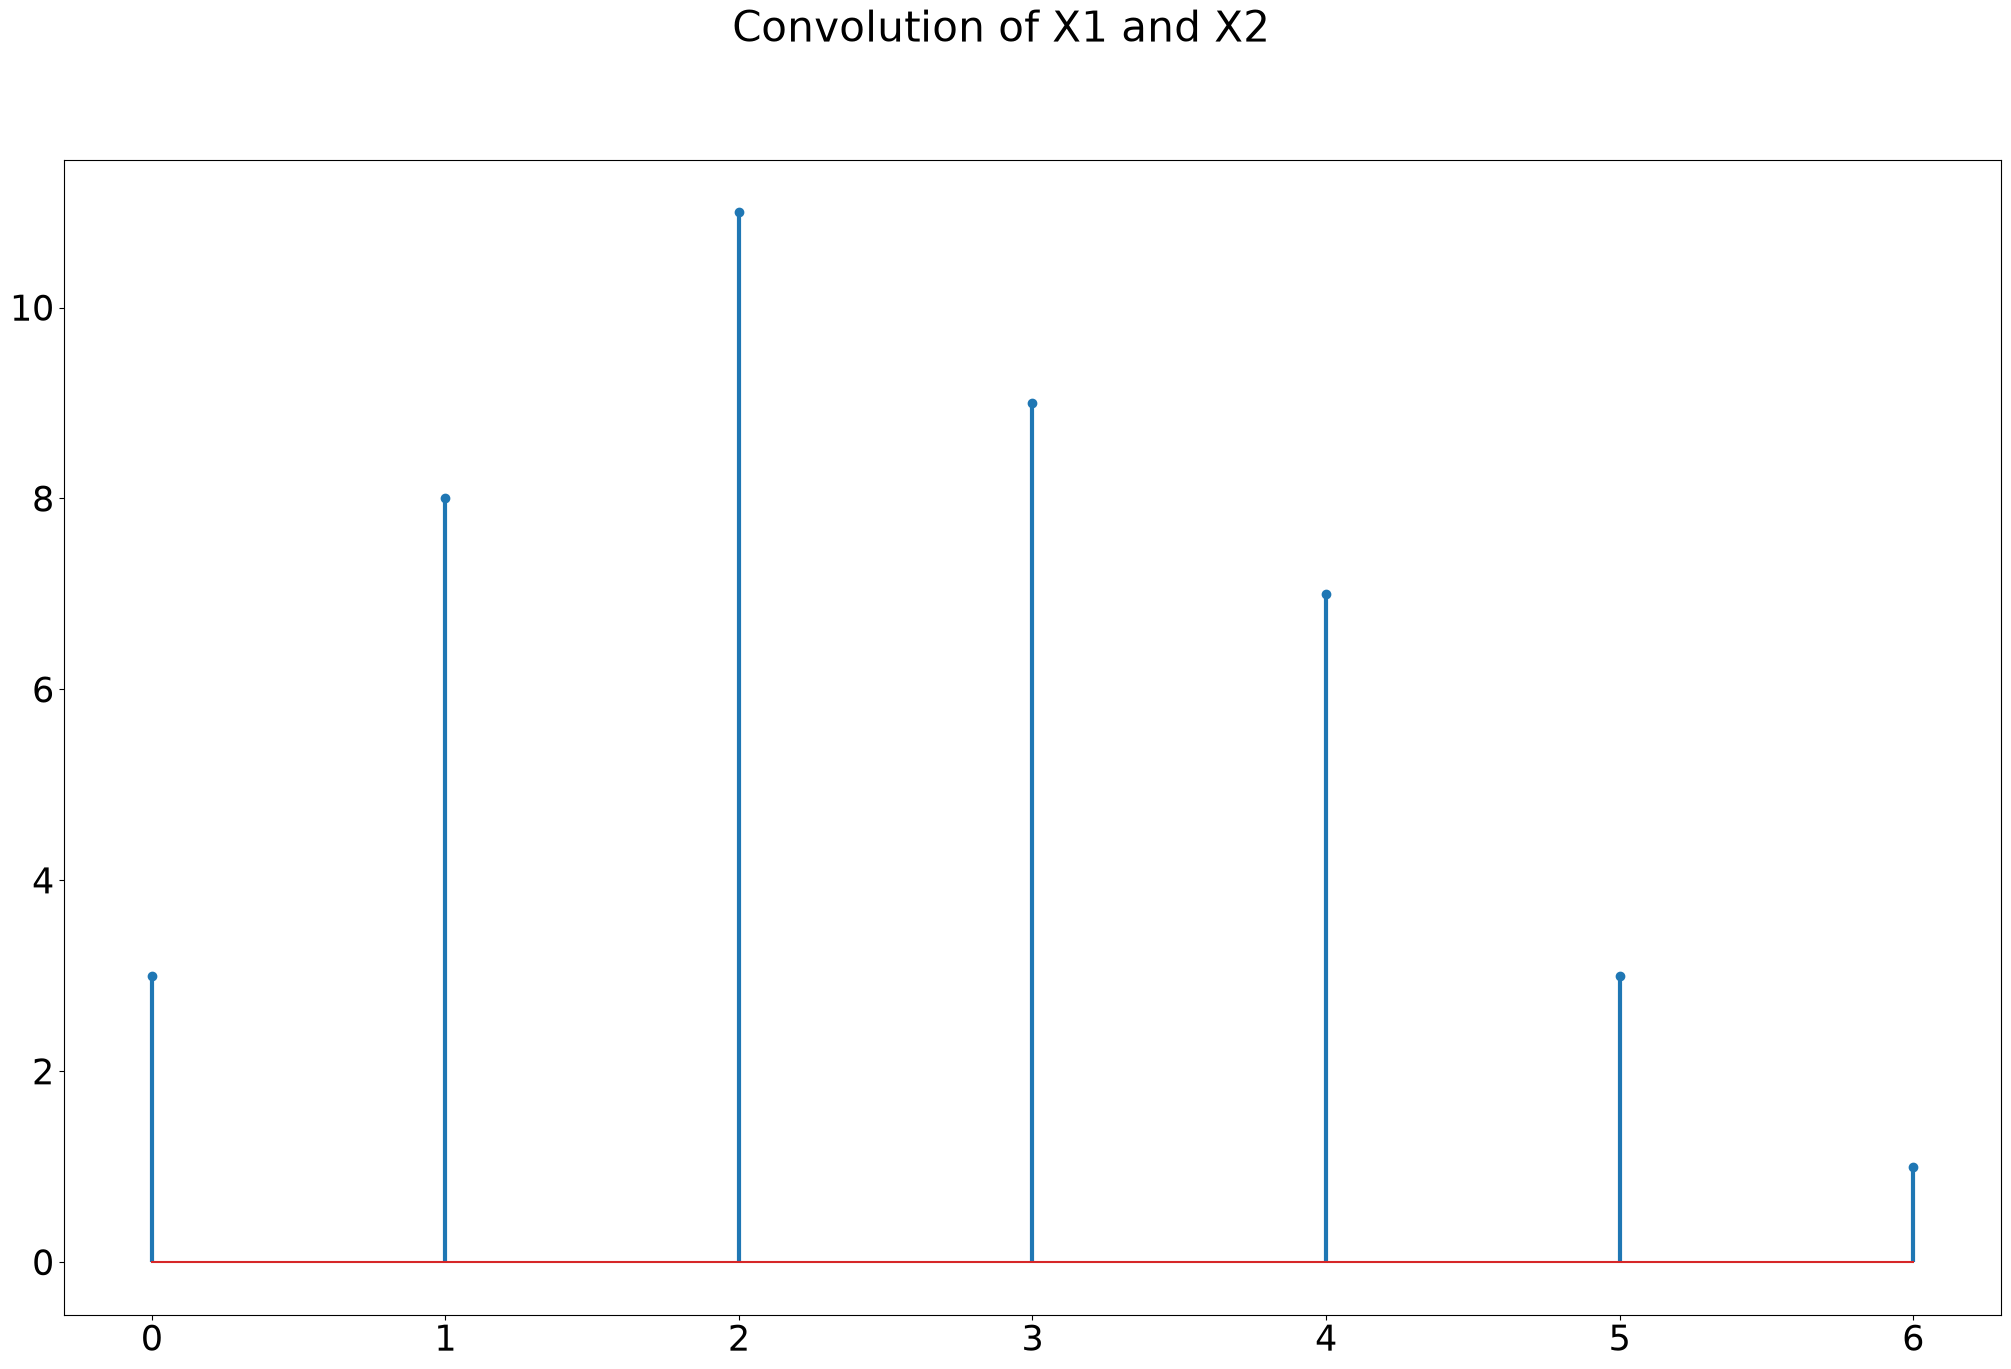

In [30]:
# Plotting convolution

plt.figure( figsize = (25,15))
plt.suptitle("Convolution of X1 and X2", fontsize=30)
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
markerline, stemlines, baseline = plt.stem(convres)
plt.setp(stemlines, 'linewidth', 3)

plt.show()